# Analisis Penentuan Jumlah Cluster pada Data Polutan Kecamatan Kamal Menggunakan K-Means dan PCA

Pada bagian ini, saya mencoba melihat apakah data polutan memiliki pola tertentu yang memungkinkan data dikelompokkan menggunakan K-Means Clustering. Analisis dilakukan melalui dua skenario. Pertama, dimensi data direduksi menggunakan Principal Component Analysis (PCA) hingga diperoleh 37 komponen utama, kemudian dilakukan K-Means Clustering. Kedua, K-Means diterapkan pada fitur asli tanpa reduksi PCA. Kedua pendekatan tersebut kemudian dibandingkan untuk mengetahui jumlah cluster yang sesuai serta seberapa baik struktur cluster yang terbentuk.

In [21]:
!pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings

warnings.filterwarnings('ignore')

# Membaca dataset
df_co = pd.read_csv("../data/ekstraksi_fitur_co.csv")
df_no2 = pd.read_csv("../data/ekstraksi_fitur_no2.csv")
df_so2 = pd.read_csv("../data/ekstraksi_fitur_so2.csv")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Penggabungan dan Pembersihan Fitur

In [22]:
# Menggabungkan dataframe
df_gabungan = pd.concat([df_co, df_no2, df_so2], axis=1)

# Memfilter kolom angka
df_numeric = df_gabungan.select_dtypes(include=[np.number, 'float64', 'int64'])

# Membuang kolom 'unnamed' dan HANYA kolom yang namanya persis 'id'
kolom_indeks = [col for col in df_numeric.columns if 'unnamed' in col.lower() or col.lower() == 'id']
df_bersih = df_numeric.drop(columns=kolom_indeks)

print(f"Total kolom murni yang siap diproses: {df_bersih.shape[1]} kolom")
display(df_bersih.head())

Total kolom murni yang siap diproses: 204 kolom


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.325552,10.822536,3,0.000892,185.172183,0.038546,0.029654,0.029505,0.021616,0.003179,...,0.148927,0.209776,1.899262e-08,0.027288,8.060801e-07,0.000153,2.160229,0.000153,2.464593e-08,93
1,0.311946,10.599365,3,0.000855,183.614501,0.036701,0.029041,0.028905,0.020794,0.002986,...,0.154508,0.292423,4.194986e-08,0.038801,6.563252e-06,0.000204,2.157516,0.000204,4.519175e-08,100
2,0.306332,10.489406,3,0.000842,180.902553,0.036488,0.028827,0.028897,0.021112,0.002878,...,0.153556,0.278411,9.647455e-08,0.064800,6.723475e-06,0.000310,2.168640,0.000310,1.002558e-07,98
3,0.320845,10.744960,3,0.000879,184.819043,0.037897,0.029439,0.029169,0.021190,0.003156,...,0.147246,0.172626,1.702950e-08,0.025822,3.133062e-06,0.000142,2.153694,0.000142,2.183313e-08,107
4,0.300128,10.334234,4,0.000831,178.342624,0.038664,0.028630,0.028280,0.021544,0.003069,...,0.147471,0.220521,1.625267e-08,0.026505,1.106266e-06,0.000132,2.167505,0.000132,1.856150e-08,108


### Standardisasi Data (Z-Score)

Sebelum PCA dan K-Means dilakukan, seluruh fitur distandarisasi menggunakan Z-Score Standardization. Tahap ini diperlukan karena fitur hasil ekstraksi dapat memiliki rentang nilai yang berbeda-beda.

Tanpa standardisasi, fitur dengan skala nilai yang lebih besar dapat memberikan pengaruh lebih besar terhadap perhitungan jarak pada K-Means maupun pembentukan komponen pada PCA.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_bersih)

### Evaluasi Klaster Optimal (Fitur Asli)

K-Means membutuhkan jumlah cluster (k) sebelum proses pengelompokan dilakukan. Karena jumlah cluster belum diketahui sebelumnya, beberapa nilai k diuji terlebih dahulu.

Pada eksperimen ini, jumlah cluster diuji mulai dari k = 2 hingga k = 10. Mnggunakan pendekatan Silhouette Score untuk membantu menentukan jumlah cluster. Silhouette Score mengukur seberapa dekat suatu observasi dengan cluster-nya sendiri dibandingkan dengan cluster lainnya. Nilai silhouette semakin mendekati 1 menunjukkan pemisahan cluster yang semakin jelas.

In [24]:
def evaluasi_cluster(data, nama_skenario, max_k=10):
    sil_scores = []
    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
        labels = kmeans.fit_predict(data)
        sil_scores.append(silhouette_score(data, labels))

    best_k = np.argmax(sil_scores) + 2
    best_score = max(sil_scores)

    print(f"--- {nama_skenario} ---")
    print(f"Jumlah cluster terbaik (K) : {best_k}")
    print(f"Skor Silhouette            : {best_score:.4f}\n")
    return best_k, best_score

evaluasi_cluster(X_scaled, "Skenario: Keseluruhan Fitur Asli (204 Dimensi)")

--- Skenario: Keseluruhan Fitur Asli (204 Dimensi) ---
Jumlah cluster terbaik (K) : 2
Skor Silhouette            : 0.7690



(np.int64(2), 0.7690133320923314)

### Reduksi Dimensi dengan Principal Component Analysis (PCA)

Data yang memiliki banyak fitur dapat menghasilkan ruang berdimensi tinggi sehingga proses clustering menjadi lebih kompleks. Untuk menyederhanakan representasi data tersebut digunakan Principal Component Analysis (PCA).

PCA mengubah fitur-fitur asli menjadi sekumpulan variabel baru yang disebut principal components. Komponen-komponen tersebut merupakan kombinasi dari fitur awal dan disusun berdasarkan besarnya variasi informasi yang dapat dijelaskan.

Pada eksperimen ini digunakan 37 komponen utama.

In [25]:
pca = PCA(n_components=37)
X_pca_37 = pca.fit_transform(X_scaled)
info_retained = np.sum(pca.explained_variance_ratio_) * 100

print(f"Persentase informasi dipertahankan oleh 37 PCA: {info_retained:.2f}%")

evaluasi_cluster(X_pca_37, "Skenario: Reduksi PCA (37 Dimensi)")

Persentase informasi dipertahankan oleh 37 PCA: 100.00%
--- Skenario: Reduksi PCA (37 Dimensi) ---
Jumlah cluster terbaik (K) : 2
Skor Silhouette            : 0.7690



(np.int64(2), 0.7690133320923314)

### Elbow Method

Selain Silhouette Score, Elbow Method digunakan untuk melihat perubahan nilai Within-Cluster Sum of Squares atau WCSS pada setiap nilai k.

Nilai WCSS akan terus menurun ketika jumlah cluster bertambah. Jumlah cluster yang sesuai biasanya terlihat pada titik ketika penurunan WCSS mulai melambat dan membentuk pola menyerupai siku.

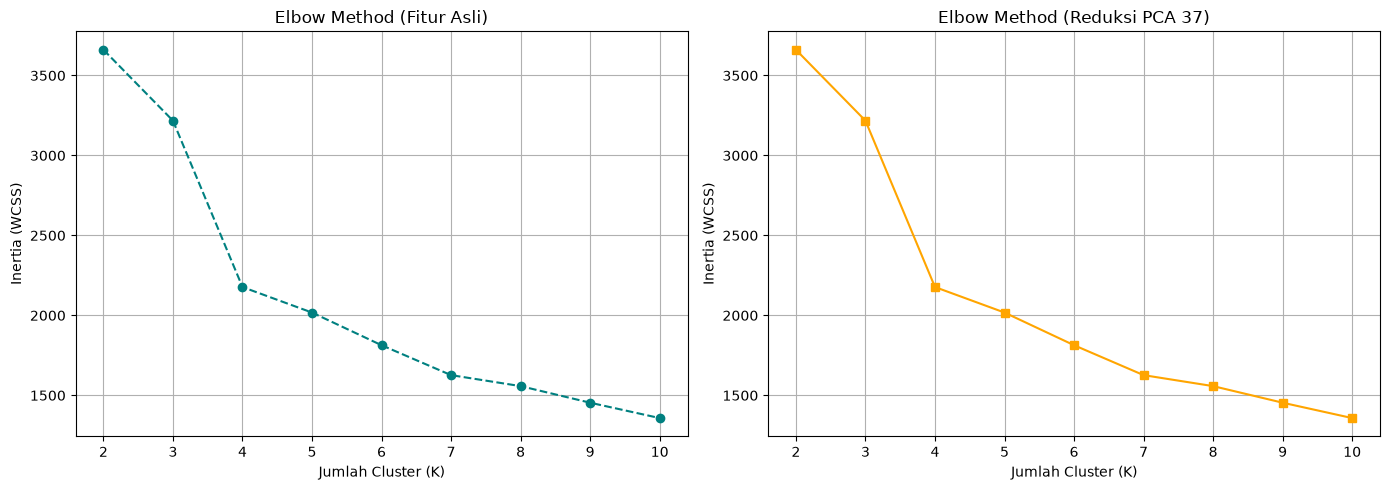

In [26]:
wcss_asli, wcss_pca = [], []
K_range = range(2, 11)

for k in K_range:
    kmeans_asli = KMeans(n_clusters=k, init='k-means++', random_state=42)
    wcss_asli.append(kmeans_asli.fit(X_scaled).inertia_)

    kmeans_pca = KMeans(n_clusters=k, init='k-means++', random_state=42)
    wcss_pca.append(kmeans_pca.fit(X_pca_37).inertia_)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, wcss_asli, marker='o', linestyle='--', color='teal')
ax[0].set_title('Elbow Method (Fitur Asli)')
ax[0].set_xlabel('Jumlah Cluster (K)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].grid(True)

ax[1].plot(K_range, wcss_pca, marker='s', linestyle='-', color='orange')
ax[1].set_title('Elbow Method (Reduksi PCA 37)')
ax[1].set_xlabel('Jumlah Cluster (K)')
ax[1].set_ylabel('Inertia (WCSS)')
ax[1].grid(True)
plt.tight_layout()
plt.show()

Hasil pengujian menunjukkan bahwa baik pada fitur asli maupun data hasil PCA 37 komponen, jumlah cluster terbaik diperoleh pada k = 2 dengan Silhouette Score sebesar 0,7690.

Nilai tersebut menunjukkan bahwa struktur dua cluster yang terbentuk cukup kuat dan memiliki pemisahan yang jelas. Kesamaan hasil pada kedua skenario juga menunjukkan bahwa reduksi dimensi menjadi 37 komponen masih mampu mempertahankan struktur clustering yang terdapat pada fitur asli.

## Implementasi Clustering Menggunakan KNIME

Selain menggunakan Python, proses clustering juga diimplementasikan menggunakan KNIME Analytics Platform. Implementasi pada KNIME digunakan untuk memperlihatkan proses pengolahan data dalam bentuk workflow visual.

Workflow terdiri dari tahapan pembacaan dataset, penggabungan fitur, pemilihan kolom, normalisasi, reduksi dimensi, clustering, dan evaluasi menggunakan Silhouette Coefficient.

![Workflow Knime](../img/workflow_knime.png)  

Pada workflow yang digunakan, setiap node memiliki fungsi yang berbeda dalam proses clustering.
1. CSV Reader digunakan untuk membaca masing-masing file dataset CO, NO₂, dan SO₂ ke dalam KNIME.
2. Column Appender digunakan untuk menggabungkan kolom dari beberapa dataset menjadi satu tabel. Penggabungan dilakukan secara horizontal sehingga fitur dari ketiga polutan berada pada satu baris yang sama.
3. Column Filter digunakan untuk memilih fitur numerik yang akan digunakan dalam clustering dan menghilangkan kolom yang tidak diperlukan, seperti kolom identitas atau indeks.
4. Normalizer digunakan untuk menyamakan skala antarfitur sebelum PCA dan K-Means dilakukan. Langkah ini penting karena K-Means menggunakan perhitungan jarak sehingga fitur dengan rentang nilai yang besar dapat mendominasi hasil clustering jika tidak dinormalisasi.
5. PCA digunakan untuk mereduksi jumlah fitur menjadi 37 principal components. Hasil dari node ini kemudian digunakan sebagai input pada K-Means untuk skenario dengan reduksi dimensi.
6. K-Means digunakan untuk mengelompokkan data berdasarkan kemiripan karakteristik fitur. Berdasarkan hasil evaluasi sebelumnya, jumlah cluster yang digunakan adalah k = 2.
7. Silhouette Coefficient digunakan untuk mengevaluasi kualitas cluster. Nilai silhouette yang lebih mendekati 1 menunjukkan bahwa anggota dalam satu cluster memiliki kemiripan yang tinggi dan memiliki jarak yang cukup jelas terhadap cluster lain.

**Clustering dengan PCA**

Pada skenario pertama, data direduksi menggunakan PCA menjadi 37 komponen utama. Hasil PCA kemudian digunakan sebagai input K-Means dengan k = 2 dan dievaluasi menggunakan Silhouette Coefficient.

![Clustering dengan PCA](../img/pca.png)  

Pada pengujian ini diperoleh Silhouette Score sebesar 0,604, yang menunjukkan bahwa dua cluster yang terbentuk memiliki pemisahan yang sangat baik.

**Clustering Tanpa PCA**

Pada skenario kedua, K-Means diterapkan langsung pada fitur hasil normalisasi tanpa melalui PCA. Jumlah cluster yang digunakan tetap k = 2, kemudian kualitas cluster dievaluasi menggunakan Silhouette Coefficient.

![Clustering tidak PCA](../img/no-pca.png) 

Hasil yang diperoleh juga menunjukkan Silhouette Score sebesar 0,604. Dengan demikian, reduksi dimensi menggunakan PCA tetap mampu mempertahankan kualitas clustering yang diperoleh dari fitur asli.

### Perbandingan Implementasi Python dan KNIME

| Implementasi | Fitur Asli | PCA 37 |
| ------------ | ---------: | -----: |
| Python       |     0,7690 | 0,7690 |
| KNIME        |      0,604 |  0,604 |


Hasil implementasi Python dan KNIME sama-sama menunjukkan bahwa **k = 2** menghasilkan struktur clustering yang baik. Namun, nilai Silhouette Score yang diperoleh berbeda, yaitu **0,7690 pada Python** dan **0,604 pada KNIME**.

Perbedaan tersebut menunjukkan bahwa konfigurasi preprocessing atau parameter model pada kedua implementasi belum sepenuhnya identik. Beberapa faktor yang dapat memengaruhi hasil antara lain metode normalisasi, konfigurasi PCA, parameter inisialisasi K-Means, serta kolom yang digunakan pada masing-masing workflow Meskipun nilai evaluasinya berbeda, kedua implementasi memberikan kesimpulan yang sama bahwa pembagian data menjadi **dua cluster** merupakan konfigurasi yang paling sesuai pada eksperimen ini.
